In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

## MIXTURE DENSITY NETWORK
 ref: http://blog.otoro.net/2015/11/24/mixture-density-networks-with-tensorflow/
  https://www.katnoria.com/mdn/

In [2]:
%%capture
!pip -q install lightning torchinfo

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

### Inverse Problem

- Normal linear regression

In [4]:
def create_book_example(n=1000):
    # Train 데이터 준비
    x_data = np.float32(np.random.uniform(-10.5, 10.5, (1, n))).T
    r_data = np.float32(np.random.normal(size=(n,1)))
    yn_data = np.float32(np.sin(0.75*x_data)*7.0 + x_data*0.5)
    y_data = np.float32(np.sin(0.75*x_data)*7.0 + x_data*0.5 + r_data*1.0)
    # Test 데이터 준비
    x_test = np.float32(np.arange(-10.5,10.5,0.05))
    x_test = x_test.reshape(x_test.size, 1)
    return x_data, y_data, x_test

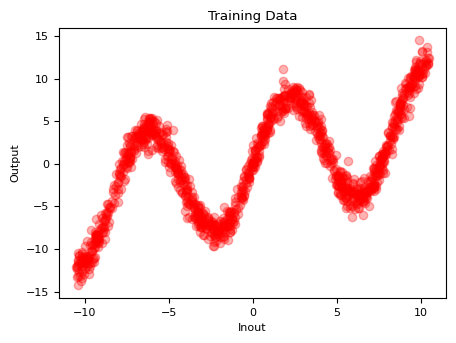

In [5]:
# Plot data (x and y)
X, y, x_test = create_book_example(n=1200)
plt.plot(X, y, 'ro', alpha=0.3)
plt.title("Training Data")
plt.xlabel('Inout')
plt.ylabel('Output')
plt.show()

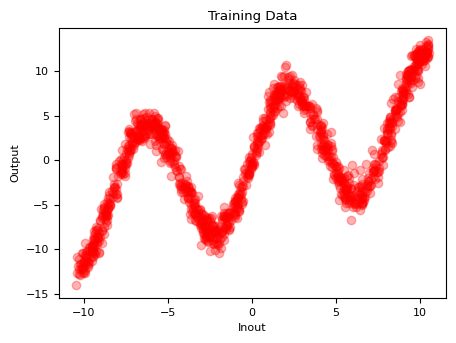

In [8]:
class CustomDataset:
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self): return len(self.x)
    def __getitem__(self, idx):
        return torch.FloatTensor(self.x[idx]), torch.FloatTensor(self.y[idx])

In [ ]:
trainDataset = CustomDataset(X, y)
trainDataLoader = DataLoader(trainDataset, shuffle=True, batch_size=64)

In [ ]:
# MLP Regression model
class MLP(L.LightningModule):
    def __init__(self, h):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, h),
            nn.PReLU(h),
            nn.Linear(h, 1))

    def forward(self, x):
        out = self.layers(x)
        return out

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.mse_loss(y_pred, y)
        metrics={'loss':loss}
        self.log('loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters())

model = MLP(h=32)#.to(device)
summary(model, input_size=(4, 1))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [4, 1]                    --
├─Sequential: 1-1                        [4, 1]                    --
│    └─Linear: 2-1                       [4, 32]                   64
│    └─PReLU: 2-2                        [4, 32]                   32
│    └─Linear: 2-3                       [4, 1]                    33
Total params: 129
Trainable params: 129
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [ ]:
%%time
model = MLP(h=32)#.to(device)

name = "MLP"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=300, logger=logger)
trainer.fit(model, trainDataLoader)
# Wall time: 23.4 s

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df = history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
plt.plot(df['loss'], linestyle='-', label=name)
#plt.semilogy()
plt.grid()
plt.legend()
plt.ylabel('Loss')
plt.legend()
plt.show()

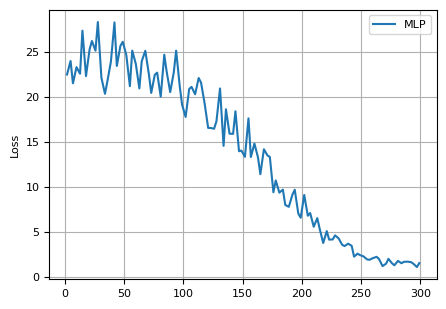

In [ ]:
import pandas as pd
import os

In [ ]:
testDataset = CustomDataset(x_test, y)
testDataLoader = DataLoader(testDataset, shuffle=False)

In [ ]:
# Prediction
model.eval()
#y_test = model.to(device)(torch.FloatTensor(x_test).to(device)).cpu().detach().numpy()
y_test = model(torch.FloatTensor(x_test)).cpu().detach().numpy()
# plot results
plt.plot(X, y, 'ro', alpha=0.3, label='Training Data')
plt.plot(x_test, y_test, 'bo', alpha=0.2, label='Regression Result')
plt.legend()
plt.title('Regression Results ')
plt.show()

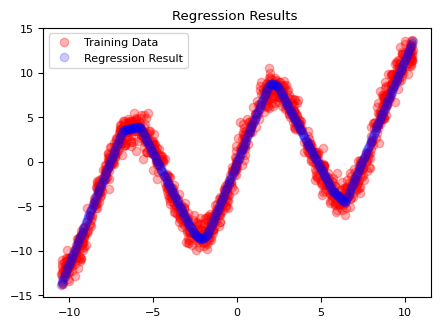

- Inverse problem

(1200, 1) (1200, 1)


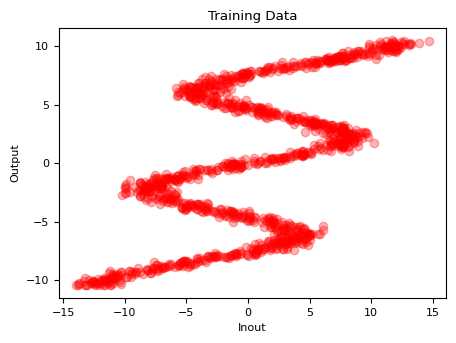

In [6]:
# Plot data (x and y)
X, y, x_test = create_book_example(n=1200)
print(X.shape, y.shape)
flipped_x = y
flipped_y = X

plt.plot(flipped_x, flipped_y, 'ro', alpha=0.3)
plt.title("Training Data")
plt.xlabel('Inout')
plt.ylabel('Output')
plt.show()

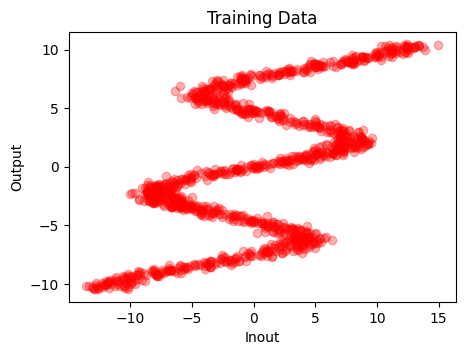

In [9]:
trainDataset = CustomDataset(flipped_x, flipped_y)
trainDataLoader = DataLoader(trainDataset, shuffle=False, batch_size=64)

In [10]:
%%time
model = MLP(h=32)#.to(device)

name = "MLP_flipped"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=300, logger=logger)
trainer.fit(model, trainDataLoader)
# Wall time: 21.7 s

NameError: name 'MLP' is not defined

In [11]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df = history.groupby('epoch').last().drop('step', axis=1)

NameError: name 'logger' is not defined

In [ ]:
plt.plot(df['loss'], linestyle='-', label=name)
#plt.semilogy()
plt.grid()
plt.legend()
plt.ylabel('Loss')
plt.legend()
plt.show()

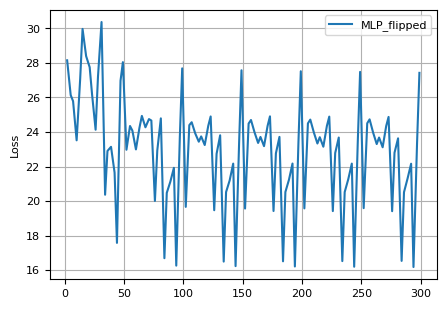

In [ ]:
# epochs 500
x_test_inv = np.linspace(-12, 12., 500).reshape(-1, 1)
y_test_inv = model(torch.FloatTensor(x_test_inv)).cpu().detach().numpy()

plt.plot(y, X, 'ro', alpha=0.3)
plt.plot(x_test_inv, y_test_inv, 'b.', alpha=0.3)
plt.show()

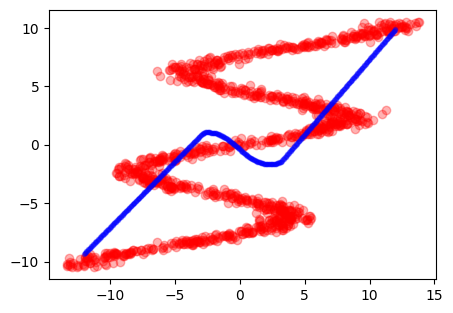

### Mixture Density Network

- 5개의 component를 갖는 Model

In [12]:
# Mixture Density Network model
f      = 1 # features
hidden = 50 # hidden layer ###
k      = 5 # components    ###

class MixtureDensity(L.LightningModule):
    @classmethod
    def add_method(cls, fun):
      setattr(cls, fun.__name__, fun)
      return fun

    def __init__(self, print_every):
        super(MixtureDensity, self).__init__()
        self.print_every = print_every
        self.layer = nn.Sequential(
                         nn.Linear(f, hidden),
                         nn.ReLU(),
                         nn.Dropout(0.1), ##
                         nn.Tanh())
        self.mu_layer  = nn.Linear(hidden, k)
        self.var_layer = nn.Linear(hidden, k)
        self.pi_layer  = nn.Sequential(
                         nn.Linear(hidden, k),
                         nn.Softmax())

    def forward(self, x):
        out = self.layer(x)
        mu = self.mu_layer(out)
        var = self.var_layer(out)
        var = torch.exp(var) # 양수값이므로 exp를 취해줌
        pi = self.pi_layer(out)
        return pi, mu, var

print_every = 500
model = MixtureDensity(print_every)
summary(model, input_size=(8, 1))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1879: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return inner()


Layer (type:depth-idx)                   Output Shape              Param #
MixtureDensity                           [8, 5]                    --
├─Sequential: 1-1                        [8, 50]                   --
│    └─Linear: 2-1                       [8, 50]                   100
│    └─ReLU: 2-2                         [8, 50]                   --
│    └─Dropout: 2-3                      [8, 50]                   --
│    └─Tanh: 2-4                         [8, 50]                   --
├─Linear: 1-2                            [8, 5]                    255
├─Linear: 1-3                            [8, 5]                    255
├─Sequential: 1-4                        [8, 5]                    --
│    └─Linear: 2-5                       [8, 5]                    255
│    └─Softmax: 2-6                      [8, 5]                    --
Total params: 865
Trainable params: 865
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass siz

In [13]:
## 학습된 확률함수와 y_true의 likelihood를 계산,
## y_true와 5개 정규분포로 부터 y의 확률을 계산
@MixtureDensity.add_method
def calc_pdf(self, y, mu, var): #(n, 5, 5)
    """Calculate component density"""
    value = (y - mu)** 2 #
    value = torch.exp(-value/(2*var))
    value = (1/torch.sqrt(2* torch.pi * var)) * value
    return value #각 y에 대한 5개의 확률값:(n, 5)

## 예측한 밀도함수 N(mu,var)에서 y확률밀도를 계산하고,
## -log(likelihood) & recuce_sum -> loss
@MixtureDensity.add_method
def mdn_loss(self, y_true, pi, mu, var):   #(n,5,5,5)
    out = self.calc_pdf(y_true, mu, var)   #(n,5)<-(n,5,5)
    out = torch.multiply(out, pi) # 확률에 가중치를 곱 #(n,5)
    out = torch.sum(out, 1, keepdim=True)  #(n,1)
    out = -torch.log(out + 1e-10)          # -log(n,1)
    return torch.mean(out)                 #(1,)

In [14]:
@MixtureDensity.add_method
def training_step(self, batch, batch_idx):
    x, y = batch
    pi, mu, var = self(x)
    loss = self.mdn_loss(y, pi, mu, var)
    self.log('loss', loss, prog_bar=True)
    return loss

@MixtureDensity.add_method
def configure_optimizers(self):
    return torch.optim.Adam(self.parameters(),lr=0.0005, weight_decay=0.0005)

@MixtureDensity.add_method
def on_train_epoch_end(self):
    if (self.trainer.current_epoch + 1) % self.print_every == 0:
        self.training_result_plot()

In [15]:
@MixtureDensity.add_method
def sample_predictions(self, pi_vals, mu_vals, var_vals, samples=10):
    n, k = pi_vals.shape  # n:420, k:5
    out = np.zeros((n, samples, f)) # (420,10,1)
    for i in range(n): # #in_sample(420)
        for j in range(samples):#aug_sample(10)
            # pi 샘플링: pi[i]에 있는 확률로 하나 선택
            #         : k선택, 샤용할 mu, var 선택
            idx = np.random.choice(range(k), p=pi_vals[i])
            for li in range(f):
                #정규분포에서 (mu[i번째x에대한][idx],var[i번째x에대한][idx])
                #            로 샘플링
                out[i,j,li] = np.random.normal(mu_vals[i, idx*(li+f)],
                                                np.sqrt(var_vals[i, idx]))
    return out #out[i번째x에대한,j번째샘플,li번째feature]:(420,10,1)

#중간결과 보여 주기
@MixtureDensity.add_method
def training_result_plot(self):
    f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, sharey=False, figsize=(12,3))
    epoch = self.trainer.current_epoch
    # Get predictions, Get samples
    x_test_tensor = torch.FloatTensor(x_test).to(device)
    self.eval() ###
    pi_vals, mu_vals, var_vals = self(x_test_tensor) #[(420,5),(420,5),(420,5)]
    sampled_predictions = self.sample_predictions(pi_vals.cpu().detach().numpy(),
                                                  mu_vals.cpu().detach().numpy(),
                                                  var_vals.cpu().detach().numpy(), 10)
    self.train() ###
    ax1.plot(flipped_x, flipped_y, 'ro', alpha=0.1)
    for i in range(sampled_predictions.shape[1]):
        ax1.plot(x_test, sampled_predictions[:, i], 'b.', alpha=0.1, label='predicted')
    ax1.axis([-12, 12, -12, 12])
    ax1.set_title(("[%d] Sampled Results") % (epoch))

    ax2.plot(x_test, mu_vals.cpu().detach().numpy(), label="Mean Functions")
    ax2.set_title(("[%d] Means : Mu(x)") % (epoch))
    ax2.axis([-12, 12, -12, 12])

    ax3.plot(x_test, pi_vals.cpu().detach().numpy(), label="Mix Functions")
    ax3.set_title(("[%d] Mixing Coeff. Pi(x)") % (epoch))

    ax4.plot(x_test, var_vals.cpu().detach().numpy(), label="Var Functions")
    ax4.set_title(("[%d] Variance Coeff. Var(x)") % (epoch))

    ax1.grid(True)
    ax2.grid(True)
    ax3.grid(True)
    plt.show()
    return var_vals

In [16]:
trainDataset = CustomDataset(flipped_x, flipped_y)
trainDataLoader = DataLoader(trainDataset, batch_size=256, shuffle=True)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'hi

Training: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


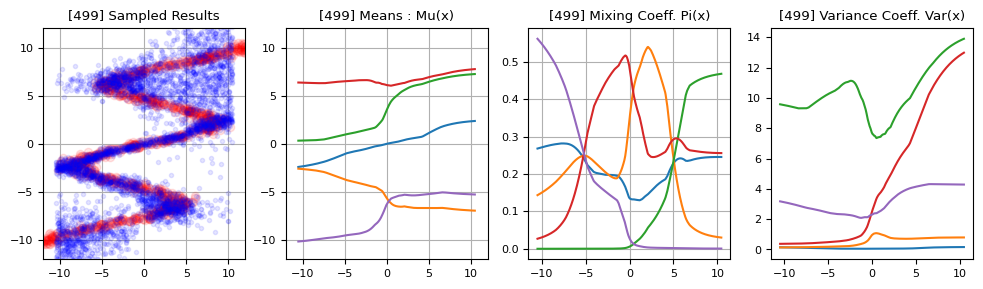

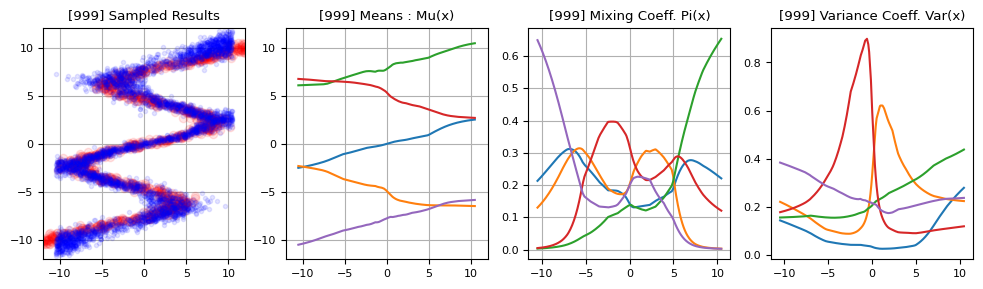

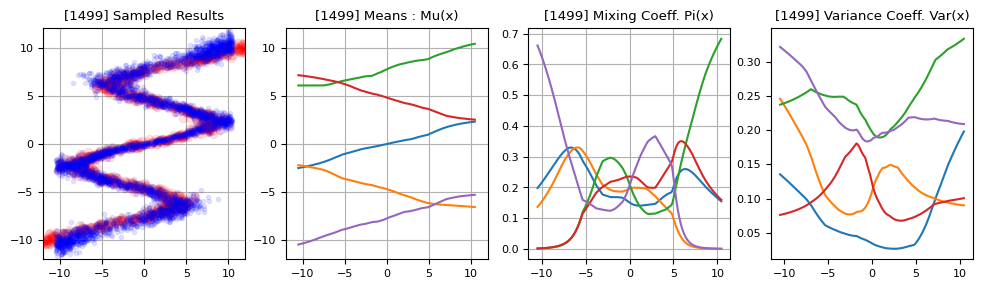

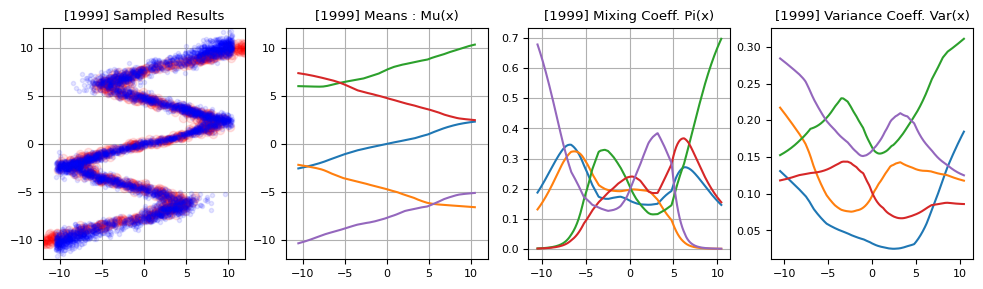

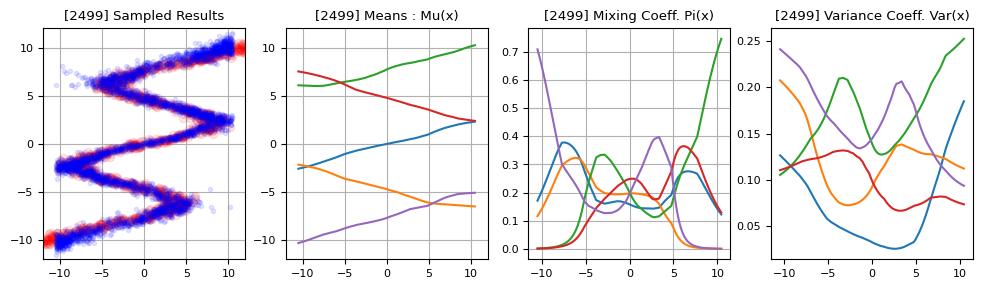

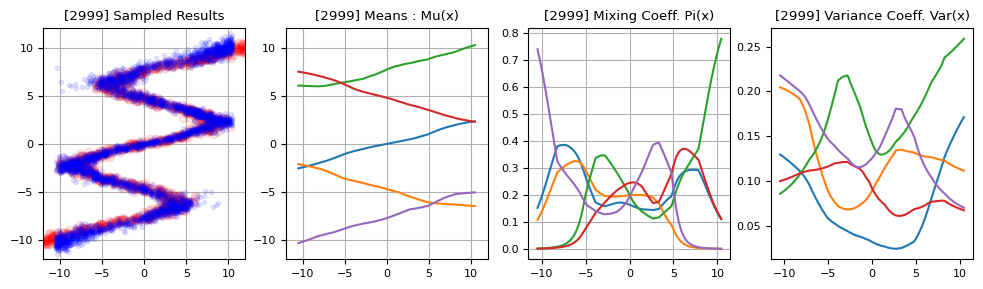

INFO: `Trainer.fit` stopped: `max_epochs=3000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3000` reached.


CPU times: user 2min 15s, sys: 5.66 s, total: 2min 21s
Wall time: 2min 18s


In [17]:
%%time
print_every = 500
model = MixtureDensity(print_every)

name = "MixtureDensity"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=3000, logger=logger)
trainer.fit(model, trainDataLoader)
# Wall time: 2min 21s

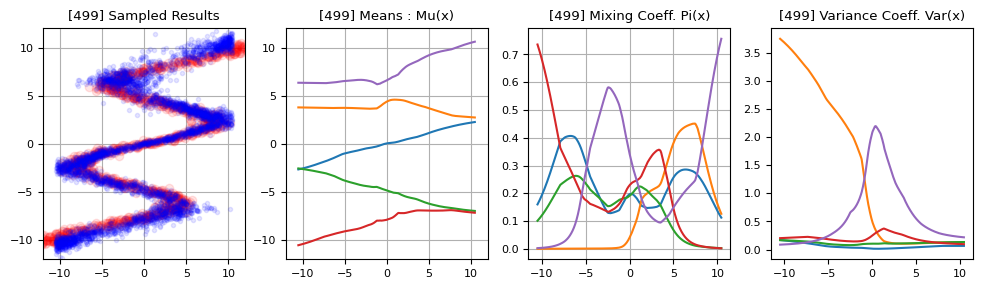

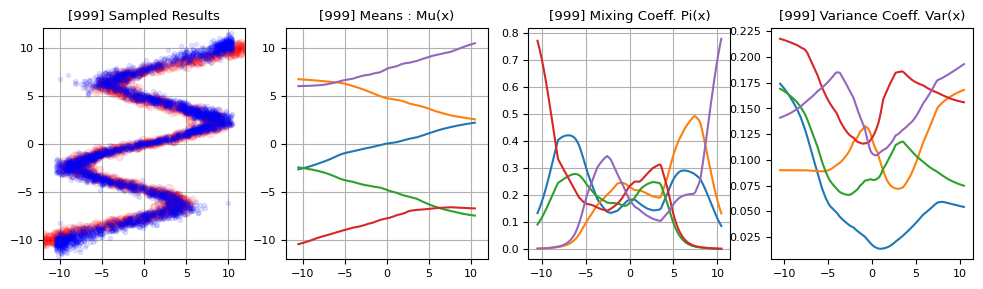

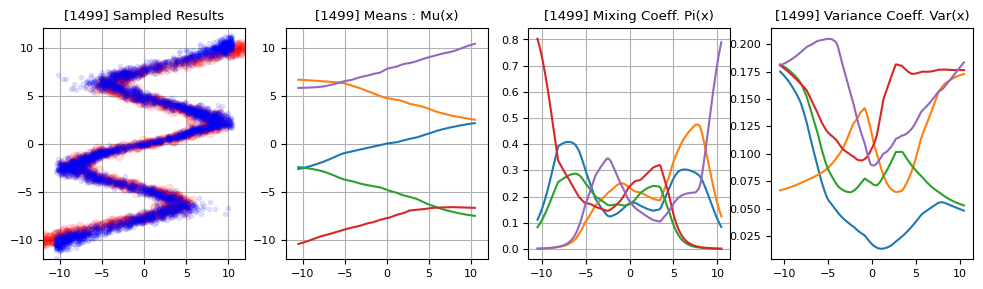

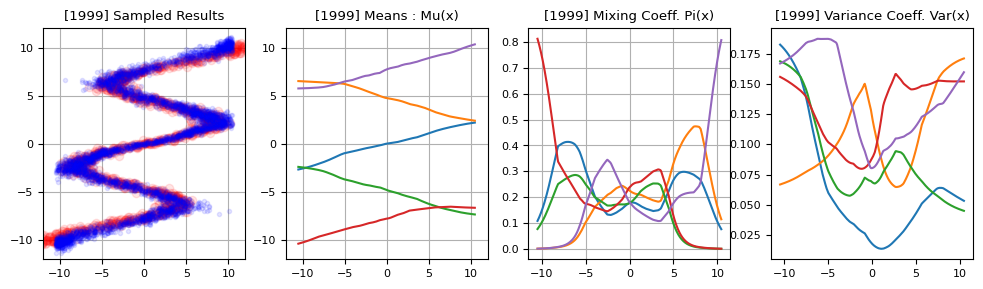

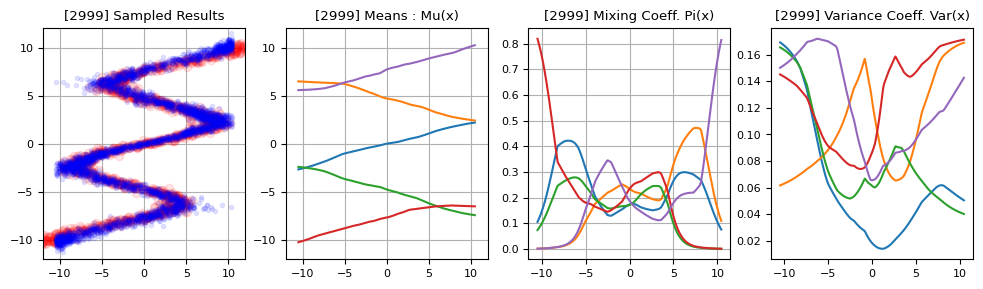

Wall time: 3min 17s

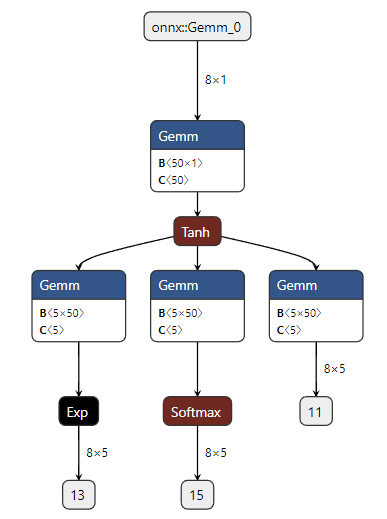

- Sampling
**학습된 확률분포에 x_test값을 넣어 sampling된 y_pred 구하기

In [ ]:
# Plot the predictions along with the flipped data
import matplotlib.patches as mpatches

# Prediction으로 확률 parameter 산출   #(420,5)x3 <- (420)
pi_vals, mu_vals, var_vals = model(torch.Tensor(x_test))
# 5개 확률분포에서 중요도에 따라 10개 sampling 하기
pi_vals = pi_vals.cpu().detach().numpy()
mu_vals = mu_vals.cpu().detach().numpy()
var_vals = var_vals.cpu().detach().numpy()
sampled_predictions = model.sample_predictions(pi_vals, mu_vals, var_vals, 10)
#sampled_predictions.shape : (420,10,1)
fig = plt.figure(figsize=(5, 5))
plt.plot(flipped_x, flipped_y, 'ro')#training data
for i in range(sampled_predictions.shape[1]): # 10
     plt.plot(x_test, sampled_predictions[:, i], 'b.', alpha=0.3, label='predicted')
patches = [ mpatches.Patch(color='red', label='Training'),
            mpatches.Patch(color='blue', label='Predicted') ]
plt.legend(handles=patches)
plt.show()

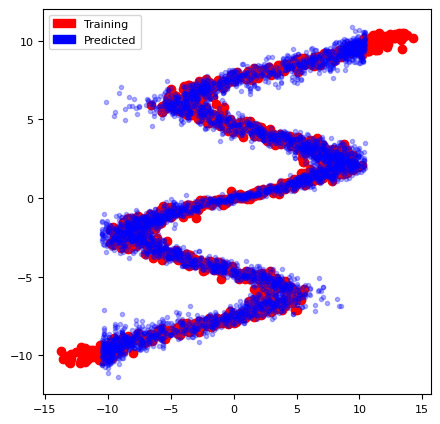

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(flipped_x, flipped_y, 'ro', alpha=0.1)
for i in range(sampled_predictions.shape[1]):
     p1=plt.plot(x_test, sampled_predictions[:, i], 'b.', alpha=0.1)
p2=plt.plot(x_test, mu_vals, linewidth=3)
#p3=plt.plot(x_test, (pi_vals*30-15))
plt.axis([-13, 13, -13, 13])
plt.title("Mean Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.legend()
plt.show()

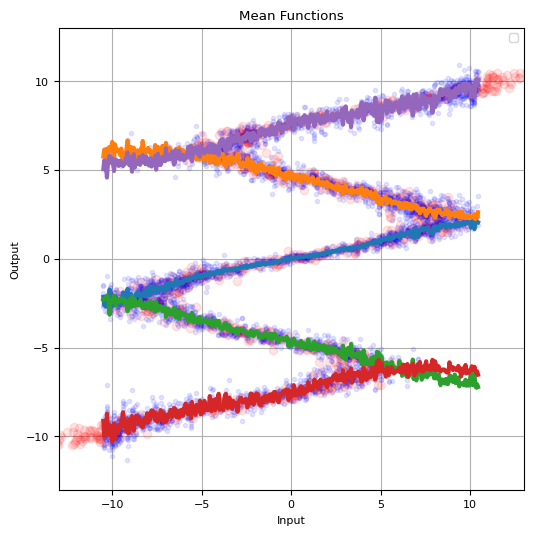